## Evaluation Metrics

### Intra-List Diversity (ILD)

**Definition:** The average pairwise dissimilarity between all items in a 
recommendation list.

**Calculation:** For every unique pair of videos (i, j) in the recommended list, 
compute `1 - cosine_similarity(i, j)`, then average across all pairs.

**Interpretation:** A higher ILD means the recommended videos are, on average, 
less similar to each other, the list spans a wider range of content rather than 
clustering around one topic. ILD = 0 would mean every video in the list is 
identical to every other; higher values indicate a more varied set of recommendations.

---

### Topic Coverage Score

**Definition:** The number of distinct topic clusters represented within a 
recommendation list.

**Calculation:** All videos in the dataset are first grouped into *k* topic 
clusters using KMeans on their embedding vectors. For a given recommendation list, 
Topic Coverage Score counts how many *unique* clusters appear among the recommended items.

**Interpretation:** A higher Topic Coverage Score means the recommendations span 
more distinct topic areas rather than repeatedly drawing from the same cluster. 
A list of 10 videos with a Topic Coverage Score of 2 is far less diverse than one 
with a score of 8, even if their ILD scores were similar... this metric captures 
diversity at the *category* level, while ILD captures it at the *pairwise distance* level.

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv('/Users/anoushka/Desktop/Diversity-Aware-Recommender/data/cleaned_videos.csv')
embeddings_weighted = np.load('/Users/anoushka/Desktop/Diversity-Aware-Recommender/data/embeddings_weighted.npy')
embedding_sim_weighted = cosine_similarity(embeddings_weighted)

print(df.shape)

(22427, 17)


In [2]:
import sys
sys.path.append('/Users/anoushka/Desktop/Diversity-Aware-Recommender/src')  

from recommender import RecommendationEngine

engine = RecommendationEngine(df, embedding_sim_weighted)

In [3]:
def intra_list_diversity(indices, similarity_matrix):
    """
    indices: list of video indices in a recommendation list
    similarity_matrix: precomputed cosine similarity matrix
    
    returns: a single diversity score (float) for this list
    """
    count = 0
    dissimilarity = 0
    for i in range(len(indices)):
        for j in range(i+1, len(indices)):
            video_i = indices[i]
            video_j = indices[j]
            dissimilarity+= 1-similarity_matrix[video_i][video_j]
            count+=1
    
    return dissimilarity/count


In [4]:
result = engine.recommend(seed_idx=0, lambda_param=0.5, top_n=10)
diversity_score = intra_list_diversity(result, embedding_sim_weighted)
print(diversity_score)

0.7861856


In [5]:
lambdas_to_test = [0, 0.25, 0.5, 0.75, 1.0]

for lam in lambdas_to_test:
    result = engine.recommend(seed_idx=0, lambda_param=lam, top_n=10)
    diversity_score = intra_list_diversity(result, embedding_sim_weighted)
    print(f"λ = {lam} -> ILD = {round(diversity_score, 4)}")

λ = 0 -> ILD = 1.007099986076355
λ = 0.25 -> ILD = 0.9864000082015991
λ = 0.5 -> ILD = 0.7861999869346619
λ = 0.75 -> ILD = 0.6873000264167786
λ = 1.0 -> ILD = 0.6151999831199646


**Note:** ILD at λ=0 slightly exceeds 1.0 (1.007), which is possible because cosine
similarity on embeddings can be negative (unlike TF-IDF, which is bounded 0-1).
At λ=0, MMR actively seeks maximally dissimilar pairs, confirming the algorithm is working as intended at the diversity extreme.

In [6]:
from sklearn.cluster import KMeans

# cluster all videos into topic groups 
n_clusters = 20
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['topic_cluster'] = kmeans.fit_predict(embeddings_weighted)

print(df['topic_cluster'].value_counts())

topic_cluster
1     2129
10    2104
18    2037
6     2009
15    1457
17    1455
5     1437
3     1345
11    1264
2     1231
4     1033
12     877
16     834
8      823
0      738
9      501
14     425
19     396
7      197
13     135
Name: count, dtype: int64


In [7]:
def topic_coverage(indices, df):
    """
    indices: list of video indices in a recommendation list
    df: dataframe with a 'topic_cluster' column
    
    returns: number of distinct topic clusters represented
    """
    clusters_seen = set()
    for index in indices:
        clusters_seen.add(df['topic_cluster'][index])
    
    return len(clusters_seen)

In [8]:
result = engine.recommend(seed_idx=0, lambda_param=0.5, top_n=10)
coverage = topic_coverage(result, df)
print(coverage)

4


In [9]:
lambdas_to_test = [0, 0.25, 0.5, 0.75, 1.0]

for lam in lambdas_to_test:
    result = engine.recommend(seed_idx=0, lambda_param=lam, top_n=10)
    coverage = topic_coverage(result, df)
    print(f"λ = {lam} -> Topic Coverage = {coverage}")

λ = 0 -> Topic Coverage = 5
λ = 0.25 -> Topic Coverage = 6
λ = 0.5 -> Topic Coverage = 4
λ = 0.75 -> Topic Coverage = 5
λ = 1.0 -> Topic Coverage = 5


**Observation:** Unlike Intra-List Diversity, which decreased monotonically and 
cleanly as λ increased (1.007 → 0.615), Topic Coverage Score shows no clear trend 
across the same λ values. It fluctuates narrowly between 4 and 6 regardless of 
how much weight is placed on diversity.

**Why the two metrics disagree:** This is likely due to three factors:

1. **Cluster granularity** — videos were grouped into 20 KMeans clusters. Topically 
distinct videos can still land in the same broad cluster, while ILD, which operates 
directly on raw pairwise cosine similarity, can detect finer-grained differences 
that cluster membership collapses.

2. **Small list size** — with `top_n=10` and ~20 clusters, the maximum possible 
coverage score is capped low, giving the metric limited resolution to show a trend 
at this list size.

3. **Cluster boundary sensitivity** — KMeans assigns hard cluster boundaries. Two 
videos with 90% embedding similarity could be split across clusters near a decision 
boundary, while two with 40% similarity could land in the same cluster, making 
cluster membership an imperfect proxy for the smooth similarity space ILD measures 
directly.

**Conclusion:** ILD is the more sensitive and reliable diversity metric at this 
list size. Topic Coverage Score, as implemented here, is better suited to larger 
recommendation lists or coarser-grained analysis (e.g., comparing diversity across 
hundreds of recommendations rather than 10). This discrepancy between two diversity 
metrics, rather than treating them as interchangeable, is itself a useful finding: 
diversity is not a single well-defined quantity, and different operationalizations 
can disagree even when measuring "the same" underlying property.

In [10]:
lambdas_to_test = [0, 0.25, 0.5, 0.75, 1.0]

print("=== top_n = 20 ===")
for lam in lambdas_to_test:
    result = engine.recommend(seed_idx=0, lambda_param=lam, top_n=20)
    coverage = topic_coverage(result, df)
    print(f"λ = {lam} -> Topic Coverage = {coverage}")

=== top_n = 20 ===
λ = 0 -> Topic Coverage = 7
λ = 0.25 -> Topic Coverage = 10
λ = 0.5 -> Topic Coverage = 8
λ = 0.75 -> Topic Coverage = 7
λ = 1.0 -> Topic Coverage = 7


Increasing list size from 10 to 20 **did not** resolve the discrepancy. 
This suggests the disagreement is not merely a 
small-sample artifact, but reflects a **structural mismatch** between what MMR optimizes 
for and what Topic Coverage measures: <br> 
- MMR's greedy algorithm maximizes pairwise 
dissimilarity at each step, which does not guarantee systematic coverage across all 
topic clusters. <br><br>
- A video can be "maximally different" from what's already selected 
without the overall list achieving broad cluster coverage, if the greedy choices 
repeatedly favor a small number of far-apart clusters rather than spreading across many.

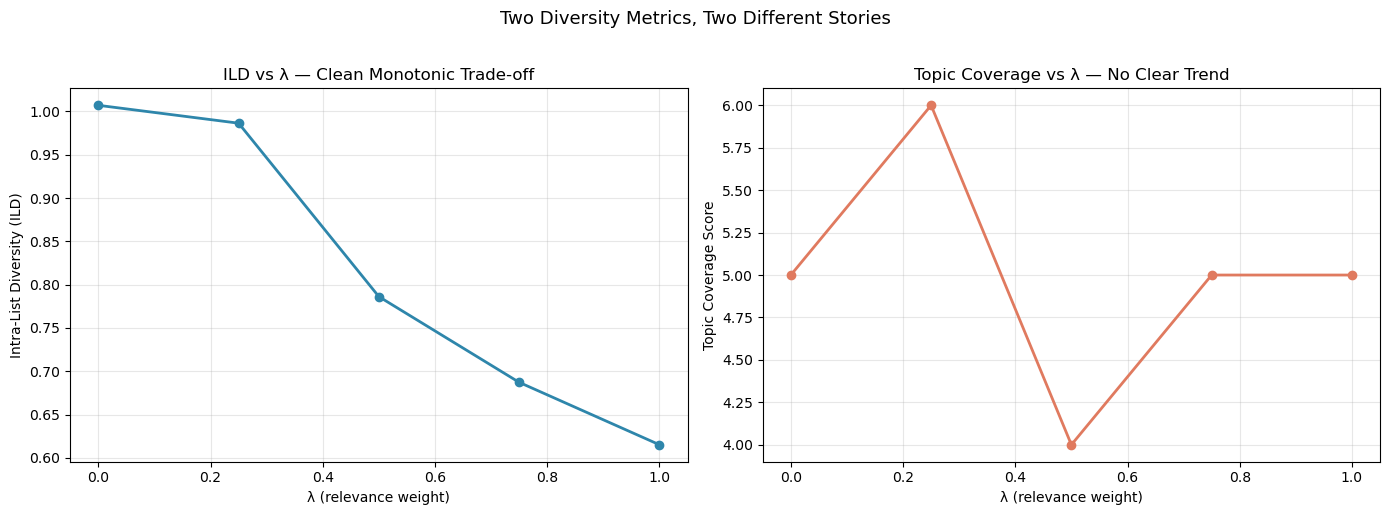

In [16]:
import matplotlib.pyplot as plt

lambdas_to_test = [0, 0.25, 0.5, 0.75, 1.0]

ild_scores = []
coverage_scores = []

for lam in lambdas_to_test:
    result = engine.recommend(seed_idx=0, lambda_param=lam, top_n=10)
    ild_scores.append(intra_list_diversity(result, embedding_sim_weighted))
    coverage_scores.append(topic_coverage(result, df))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: ILD
axes[0].plot(lambdas_to_test, ild_scores, marker='o', linewidth=2, color='#2E86AB')
axes[0].set_xlabel('λ (relevance weight)')
axes[0].set_ylabel('Intra-List Diversity (ILD)')
axes[0].set_title('ILD vs λ — Clean Monotonic Trade-off')
axes[0].grid(True, alpha=0.3)

# Panel 2: Topic Coverage
axes[1].plot(lambdas_to_test, coverage_scores, marker='o', linewidth=2, color='#E07A5F')
axes[1].set_xlabel('λ (relevance weight)')
axes[1].set_ylabel('Topic Coverage Score')
axes[1].set_title('Topic Coverage vs λ — No Clear Trend')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Two Diversity Metrics, Two Different Stories', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('diversity_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cluster-Aware Re-ranking Experiment

Testing whether explicitly forcing topic-cluster spread (rather than relying on
MMR's greedy pairwise selection) closes the gap between ILD and Topic Coverage
observed earlier. Compares a cluster-aware variant against pure MMR at the same
λ values.

In [11]:
def best_in_cluster(cluster_num, candidates, df, seed_idx, similarity_matrix):
    """
    cluster_num: which cluster to search within
    candidates: full list of candidate indices
    returns: the single candidate index in this cluster with highest relevance to seed_idx
    """
    cluster_candidates = [c for c in candidates if df['topic_cluster'][c] == cluster_num]
    
    if len(cluster_candidates) == 0:
        return None  # this cluster has no candidates left
    
    # among cluster_candidates, find whichever has the highest similarity to seed_idx
    best = max(cluster_candidates, key=lambda c: similarity_matrix[seed_idx][c])
    return best

In [12]:
def cluster_aware_recommend(seed_idx, similarity_matrix, df, top_n, n_clusters=20):
    """
    seed_idx: index of seed video
    similarity_matrix: precomputed cosine similarity matrix
    df: dataframe with 'topic_cluster' column
    top_n: how many videos to recommend
    n_clusters: how many clusters to pull from first
    
    returns: list of selected video indices
    """
    candidates = [i for i in range(len(df)) if i != seed_idx]
    selected = []
    
    # pick the single best candidate from each cluster
    for cluster_num in range(n_clusters):
        best = best_in_cluster(cluster_num, candidates, df, seed_idx, similarity_matrix)
        if best is not None:
            selected.append(best)
            candidates.remove(best)
        if len(selected) >= top_n:
            break
    
    # if we still need more items than we have clusters, fill the rest with MMR
    while len(selected) < top_n:
        scores = {}
        for candidate in candidates:
            relevance = similarity_matrix[seed_idx, candidate]
            redundancy = max([similarity_matrix[candidate, s] for s in selected])
            mmr_score = 0.5 * relevance - 0.5 * redundancy
            scores[candidate] = mmr_score
        
        max_score_candidate = max(scores, key=scores.get)
        selected.append(max_score_candidate)
        candidates.remove(max_score_candidate)
    
    return selected[:top_n]

In [13]:
# cluster-aware version
result_cluster = cluster_aware_recommend(seed_idx=0, similarity_matrix=embedding_sim_weighted, df=df, top_n=10, n_clusters=20)
print("Cluster-aware ILD:", intra_list_diversity(result_cluster, embedding_sim_weighted))
print("Cluster-aware Topic Coverage:", topic_coverage(result_cluster, df))

# pure MMR at lambda=0.5, for comparison
result_mmr = engine.recommend(seed_idx=0, lambda_param=0.5, top_n=10)
print("\nMMR (λ=0.5) ILD:", intra_list_diversity(result_mmr, embedding_sim_weighted))
print("MMR (λ=0.5) Topic Coverage:", topic_coverage(result_mmr, df))

Cluster-aware ILD: 0.7228355
Cluster-aware Topic Coverage: 10

MMR (λ=0.5) ILD: 0.7861856
MMR (λ=0.5) Topic Coverage: 4


 ## Multi-Seed Validation

Earlier evaluation was based primarily on a small number of hand-picked seed
videos. To test whether the ILD/λ and Topic Coverage/λ patterns generalize,
this section runs the same evaluation across 20 randomly sampled seed videos
and reports the average at each λ.

In [12]:
import random

random.seed(42)
random_seeds = random.sample(range(len(df)), 20)

results = []
for seed in random_seeds:
    for lam in [0, 0.25, 0.5, 0.75, 1.0]:
        rec = engine.recommend(seed_idx=seed, lambda_param=lam, top_n=10)
        ild = intra_list_diversity(rec, embedding_sim_weighted)
        coverage = topic_coverage(rec, df)
        results.append({'seed': seed, 'lambda': lam, 'ild': ild, 'coverage': coverage})

results_df = pd.DataFrame(results)
summary = results_df.groupby('lambda')[['ild', 'coverage']].agg(['mean', 'std'])
print(summary)

             ild           coverage          
            mean       std     mean       std
lambda                                       
0.00    1.011046  0.000000     6.00  0.000000
0.25    0.999444  0.013564     5.30  1.031095
0.50    0.750338  0.088037     5.15  0.933302
0.75    0.416915  0.254954     2.75  1.888330
1.00    0.342953  0.214403     2.20  1.321881
